In [15]:
import os
import glob
import random
import warnings
import numpy as np
from scipy import io
from tqdm import tqdm


from utils.plots import *
from utils.data import *
from utils.stats_perform import *
import utils.drl as utils
from utils.path import PathConfig,FigureWithData,save_figure_pdf
from rl.agent import *
import rl.plots as rlplt

seed_value=1234
random.seed(seed_value)
np.random.seed(seed_value)
warnings.filterwarnings("ignore")


fig_dir = os.path.join('figures', 'figure_7')
data_fig_dir = os.path.join('data', 'source_data', 'figure_7')
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(data_fig_dir, exist_ok=True)




In [2]:
paths = PathConfig()
save_dir = paths.save_dir
g_dir = paths.g_dir

groups = ['control','lesion']
var_names = ['input_fr','da_conc','d1_occ','d2_occ']
colors_g = ['black','red','purple']
tr_rew = ['reward','omission']
tr_cs = ['90%','50%','10%']
f_size = 12
alpha_p = .05
max_trials = 200
n_samp = 3900
nf = [45,44]

## Analysis of biophysical simulations

This notebook reproduces the analysis performed on the output variables from the biophysical simulation.

**Note:** To plot and use the present notebook the user needs to download the data inside `raw_data` folder of the OSF repository. Look at  `download_data` for the code to do this.


### Additional information on data format: 

**Trial types**

- `1`:  90% rewarded
- `2`:  90% omission
- `3`:  50% rewarded
- `4`:  50% omission
- `5`:  10% rewarded
- `6`:  10% omission

Output variables from loading: 
- `mu_var_cells`: (N groups) x(N variables) x (N trialtypes) x (N reward types) x (N cells) x (N samples per trial) 
- `single_trial_var_cells`: (N groups) x(N variables) x (N trialtypes) x (N reward types) x (N cells) x (N samples per trial) x (N trials)

Where: 
- N groups = 2  (control, lesion)
- N variables = 4 (input firing rate, DA concentration, D1 occupancy, D2 occupancy)
- N trialtypes = 6 (90% reward, 50% reward, 10% reward)
- N reward types = 2 (rewarded, omission)
- N cells = 45, 44 for each group
- N samples per trial = 3900 (`n_samp`)

In [16]:

id_trial_plot = [[1,3,5],[2,4,6]] 
mu_var_cells = np.empty((len(groups),len (var_names),len(id_trial_plot),len(id_trial_plot[0]),45,n_samp))
single_trial_var_cells =  np.empty((len(groups),len(var_names),len(id_trial_plot),len(id_trial_plot[0]),45,n_samp,max_trials))
for ig in np.arange(len(groups)):
    data_path = os.path.join(g_dir,'raw_data', groups[ig])
    file_list = glob.glob(data_path + "/*.pickle")
    print('loading ' + groups[ig])
    file_list = file_list[:nf[ig]]
    for (id_unit) in  tqdm(range(len(file_list))):
        with open(file_list[id_unit], 'rb') as handle:
            unit = pickle.load(handle)
        trial_types, trial_names = unit['data']['TrialTypes'], unit['data']['TrialNames']
        temp = np.asarray(unit['simulation_results']['time_ax'])
        ind = np.unravel_index(np.argmax(temp, axis=None), temp.shape)
        for iv in np.arange(len(var_names)):
            var_name = var_names[iv]
            var = np.asarray(unit["simulation_results"][var_name])
            # exec('var = np.asarray(unit["simulation_results"].' + var_name + ')')
            time_ax = np.asarray(unit['simulation_results']['time_ax'])[:,ind[1]]
            for ir in np.arange(len(id_trial_plot)):
                for i in np.arange(len(id_trial_plot[ir])):
                    id_trials = np.argwhere(np.isin(trial_types, id_trial_plot[ir][i])==1)[:,0]
                    id_trials = id_trials[id_trials<max_trials]
                    var_trials = var[:,id_trials]
                    var_trials[var_trials<=0] = np.nan
                    if iv==1:
                        var_trials[var_trials>3000]=np.nan # TODO
                    elif iv>=2:
                        var_trials[var_trials>1]=np.nan
                    mu_var = np.nanmean(var_trials,axis=1)
                    mu_var_cells[ig,iv,ir,i,id_unit,:]=mu_var
                    single_trial_var_cells[ig,iv,ir,i,id_unit,:,0:var_trials.shape[1]]= var_trials
                    ids_ = [np.argwhere(ii==0).flatten() for ii in single_trial_var_cells[ig,iv,ir,i,id_unit,:,:].T]
                    for (ii,ids) in enumerate(ids_):
                        single_trial_var_cells[ig,iv,ir,i,id_unit,ids,ii] = np.nan

loading control


100%|██████████| 45/45 [00:05<00:00,  8.73it/s]


loading lesion


100%|██████████| 44/44 [00:04<00:00,  9.10it/s]


**Compute responses on epochs of interest**

Output variable:
- `trial_var_cells`: (N groups) x (N variables) x (N epochs) x (N cells) x (N trial types) x (N Trials)

Where: 
- N groups      = 2  (control, lesion)
- N variables   = 4 (input firing rate, DA concentration, D1 occupancy, D2 occupancy)
- N epochs      = 3 (CS, US, baseline)
- N trialtypes  = 6 (90% omission, 50% omission, 10% omission, 90% reward, 50% reward, 10% reward)
- N cells       = 45, 44 for each group
- N trials      = 200 (`max_trials`)

In [17]:
# Windows of responses : CS, US, baseline
window_lists = [[ [16,16.3],[18,18.3],[14.5,15.5]], [[15.8,16.8],[18,19],[14.5,15.5]]]  
idwindow = [0,1,1,1] # indeces of windows to use per variable (shorter for firing rates)
# Trial ids for  unrewarded| rewarded for each trial type
ir_it =[[1,0],[1,1],[1,2],[0,0],[0,1],[0,2]]
n_trial_types = 6
n_cells = 45
n_epochs = 3
trial_var_cells = np.empty((len(groups),len(var_names),n_epochs,n_cells,n_trial_types,max_trials))
for ig in np.arange(len(groups)):
    print(' ------------ Group : '+  groups[ig] + '------------')
    for iv in np.arange(4):
        window_list = window_lists[idwindow[iv]]
        print(' ------------ Variable : '+ var_names[iv] + '------------')
        for it in np.arange(n_trial_types):
            ir,ii = ir_it[it][0],ir_it[it][1] # unrewarded | rewarded
            var_trials = single_trial_var_cells[ig,iv,ir,ii,:,:,:]
            var_trials[var_trials<=0]=np.nan
            if iv>=2:
                var_trials[var_trials>1]=np.nan
            for iw in np.arange(len(window_list)):
                id_s = np.argwhere(time_ax>window_list[iw][0])[0]
                id_e = np.argwhere(time_ax>window_list[iw][1])[0]
                mu_epoch = np.nanmean(var_trials[:,np.arange(id_s[0],id_e[0]),:],axis=1)
                trial_var_cells[ig,iv,iw,:,it,0:mu_epoch.shape[1]] = mu_epoch

 ------------ Group : control------------
 ------------ Variable : input_fr------------
 ------------ Variable : da_conc------------
 ------------ Variable : d1_occ------------
 ------------ Variable : d2_occ------------
 ------------ Group : lesion------------
 ------------ Variable : input_fr------------
 ------------ Variable : da_conc------------
 ------------ Variable : d1_occ------------
 ------------ Variable : d2_occ------------


**Compute distribution of $\tau s$ based on single-cell responses**

For each group and neuron:  

1. Select independent variable = DA concentration (id = 1)
2. Select dependent variables = D1 occupancy for positive responses, D2 occupancy for negative responses
   
      Select the epoch responses at US and at baseline for each variable and perform baseline subtraction
3. Compute **utility axis** based on the mean across neurons and trials for the indpendent variable
4. Compute the **zero crossing points** for each single neuron 
5. Compute the **asymmetric learning rates** ($\alpha_i^+$,$\alpha_i^-$) for each single neuron using the zero crossing point from step (5). 
   
   The asymmetric scaling factors are computed using a linear and logarithmic scaling of the independent variable
6. Compute the **asymmetric scaling factor** ($\tau_i = \frac{\alpha_i^+}{\alpha_i^+ + \alpha_i^-}$) 


Output variables:

- `taus_v`:  distribution of $\tau_i$ for each neuron and each group (N cells x N groups)
- `taus_log`:  distribution of $\tau_i$ for each neuron and each group using a logarithmic scaling of DA concentration (N cells x N groups)
- `alpha_pos`:  distribution of $\alpha_i^+$ for each neuron and each group (N cells x N groups)
- `alpha_pos_log`:  distribution of $\alpha_i^+$ for each neuron and each group using a logarithmic scaling of DA concentration (N cells x N groups)
- `alpha_neg`:  distribution of $\alpha_i^-$ for each neuron and each group (N cells x N groups)
- `alpha_neg_log`:  distribution of $\alpha_i^-$ for each neuron and each group using a logarithmic scaling of DA concentration (N cells x N groups)

In [18]:
n_cells = 45
i_win_base, i_win_us = 2, 1 # epochs indeces according to above variable trial_var_cells
method_regress = 'siegelslopes' 
method_zcross = 'count'
alpha_neg = np.zeros((n_cells,2))
alpha_neg_log = np.zeros((n_cells,2))
taus_v = np.zeros((n_cells,2))
taus_log = np.zeros((n_cells,2))
alpha_pos = np.zeros((n_cells,2))
alpha_pos_log  = np.zeros((n_cells,2))

for i_group in np.arange(2):
    tr_var_cells = trial_var_cells.copy()
    base_cells = tr_var_cells[i_group,1,i_win_base,:,:,:]
    per_cell = tr_var_cells[i_group,1,i_win_us,:,:,:]
    per_cell = per_cell - base_cells
    da_us =  tr_var_cells[i_group,1,i_win_us,:,:,:]
    rec_occ_pos =  tr_var_cells[i_group,2,i_win_us,:,:,:]
    rec_occ_neg = tr_var_cells[i_group,3,i_win_us,:,:,:]
    da_base = tr_var_cells[i_group,1,i_win_base,:,:,:]
    occ_base_pos = tr_var_cells[i_group,2,i_win_base,:,:,:]
    occ_base_neg = tr_var_cells[i_group,3,i_win_base,:,:,:]
    (da_us,rec_occ_pos,rec_occ_neg,da_base,occ_base_pos,occ_base_neg) = [replace_zeros_to_nan(var) for var in [da_us,rec_occ_pos,rec_occ_neg,da_base,occ_base_pos,occ_base_neg]]
    utility_axis = np.nanmean(np.nanmean(per_cell,axis=2),axis=0)
    for i_cell in np.arange(per_cell.shape[0]):
        per_cell_i = per_cell[i_cell,:,:]
        zcr = utils.compute_zero_crossings(per_cell_i,utility_axis,1, method_zcross)           
        utility_cell = utility_axis -zcr[0][0]
        id_pos = np.argwhere(utility_cell>=0)
        id_neg = np.argwhere(utility_cell<=0)
        xx_pos= (da_us[i_cell,id_pos,:]-da_base[i_cell,id_pos,:]).flatten()
        yy_pos= (rec_occ_pos[i_cell,id_pos,:]-occ_base_pos[i_cell,id_pos,:]).flatten()
        xx_pos_log= (np.log10(da_us[i_cell,id_pos,:]/occ_base_pos[i_cell,id_pos,:])).flatten()
        xx_neg = (da_us[i_cell,id_neg,:]-da_base[i_cell,id_neg,:]).flatten()
        xx_neg_log = (np.log10(da_us[i_cell,id_neg,:]/da_base[i_cell,id_neg,:])).flatten()  
        yy_neg = (rec_occ_neg[i_cell,id_neg,:]-occ_base_neg[i_cell,id_neg,:]).flatten()
        taus_log[i_cell,i_group],taus_v[i_cell,i_group],\
            alpha_pos[i_cell,i_group],alpha_pos_log[i_cell,i_group],\
                alpha_neg[i_cell,i_group],alpha_neg_log[i_cell,i_group] = utils.compute_asymmetric_scaling_receptor(xx_pos,xx_pos_log,yy_pos,xx_neg,xx_neg_log,yy_neg,method_regress=method_regress)
taus_log[taus_log>1]=np.nan
taus_log[taus_log<0]=np.nan
taus_v[taus_v>1]=np.nan
taus_v[taus_v<0]=np.nan
tau_log_cells  =taus_log.copy()
tau_lin_cells  =taus_v.copy()

**Plot of distributions of $\tau_i$**

The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis cannot be rejected
Saved figure to figures/figure_7/figure_7_extra_tau_comparison.pdf
Saved data and stats to data/source_data/figure_7/figure_7_extra_tau_comparison.txt


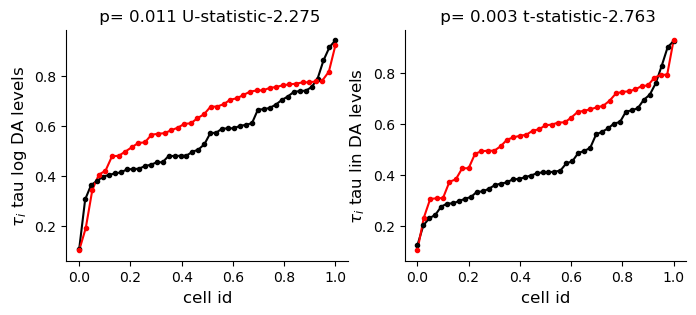

In [19]:

name_preffs = ['tau_log','tau_lin']
var_names_x = ['DA_levels']
to_test = [[taus_log],[taus_v]]
name_suff = [vi for vi in var_names_x]
alternative = 'less'

fig,ax = plt.subplots(1,2,figsize=(8,3))
fig_data_tau_comparison = FigureWithData(fig)
for ((iis,name_preff),gtest) in zip(enumerate(name_preffs),to_test):
    groups_test = [[ ti[:,i][~np.isnan(ti[:,i])] for i in range(2) ] for ti in gtest]
    # Prepare data: pad to equal length for saving
    max_len = max(len(groups_test[0][0]), len(groups_test[0][1]))
    data_padded = np.full((max_len, 2), np.nan)
    data_padded[:len(groups_test[0][0]), 0] = np.sort(groups_test[0][0])
    data_padded[:len(groups_test[0][1]), 1] = np.sort(groups_test[0][1])

    # Add the τ data
    fig_data_tau_comparison.add_data(
        f"Sorted taus comparison ({name_preff})",
        data_padded,
        ['Tau_Control', 'Tau_Lesion']
    )

    tests_pd = get_tests_table(groups_test, name_preff, name_suff,alternative=alternative, restart_pd=True)
    gnames = name_preff + '_'+name_suff[0]
    ll = len(tests_pd[(tests_pd['name_test'] == 'normaltest') & (tests_pd['group_name'] == name_preff +'_all')].pvals.to_numpy()[0])
    ss = np.sum(tests_pd[(tests_pd['name_test'] == 'normaltest') & (tests_pd['group_name'] ==name_preff +'_all')].pvals.to_numpy()[0]>.05)
    if ll>ss:
        pvals = tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_name'] == gnames)].pvals.to_numpy()[0]
        stats_p = tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_name'] == gnames)].stats.to_numpy()[0]  
        stats_n = tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_name'] == gnames)].stat_name.to_numpy()[0]  
        test_n = 'ranksum'
    else:
        pvals = tests_pd[(tests_pd['name_test'] == 'ttest') & (tests_pd['group_name'] ==gnames)].pvals.to_numpy()[0]
        stats_p = tests_pd[(tests_pd['name_test'] == 'ttest') & (tests_pd['group_name'] == gnames)].stats.to_numpy()[0]   
        stats_n = tests_pd[(tests_pd['name_test'] == 'ttest') & (tests_pd['group_name'] == gnames)].stat_name.to_numpy()[0]  
        test_n = 't-test'    
    [ax[iis].plot(np.linspace(0,1,len(groups_test[0][ig])),np.sort(groups_test[0][ig]),color=colors_g[ig]) for ig in range(2) ] 
    [ax[iis].plot(np.linspace(0,1,len(groups_test[0][ig])),np.sort(groups_test[0][ig]),'.',color=colors_g[ig]) for ig in range(2) ] 
    ax[iis].set_title(' p= '+str(np.floor(pvals*1000)/1000) + ' '+stats_n+ str(np.floor(stats_p*1000)/1000) )
    plot_config(ax[iis],'cell id',r'$\tau_i$' + ' '+gnames.replace('_',' '),12,False) 

    # Add the stat results
    stat_array = np.array([[pvals, stats_p]])
    stat_headers = ['p_value', 'test_statistic']

    fig_data_tau_comparison.add_stats(
        f"Statistical test ({test_n}, {stats_n}) for {name_preff}",
        stat_array,
        stat_headers
    )

# 3. Save everything
fig_data_tau_comparison.save(
    base_filename='figure_7_extra_tau_comparison',
    folder_data= data_fig_dir,
    folder_figures= fig_dir
)

## Figure 7c
Compute tuning curves : change in D1R and D2R occupancy as a function of changes in DA concentration

Saved figure to figures/figure_7/figure_7c_mean_tuning.pdf
Saved data and stats to data/source_data/figure_7/figure_7c_mean_tuning.txt
Saved figure to figures/figure_7/figure_7c_single_cell_tuning.pdf
Saved data and stats to data/source_data/figure_7/figure_7c_single_cell_tuning.txt


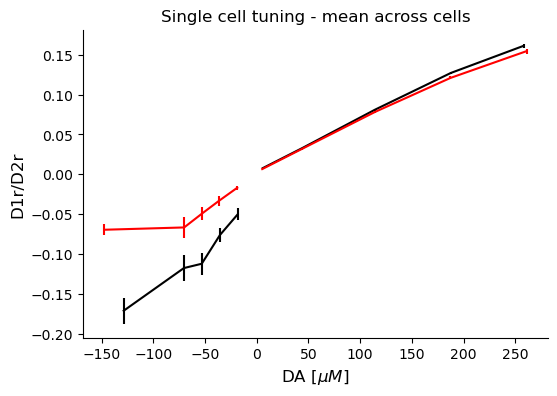

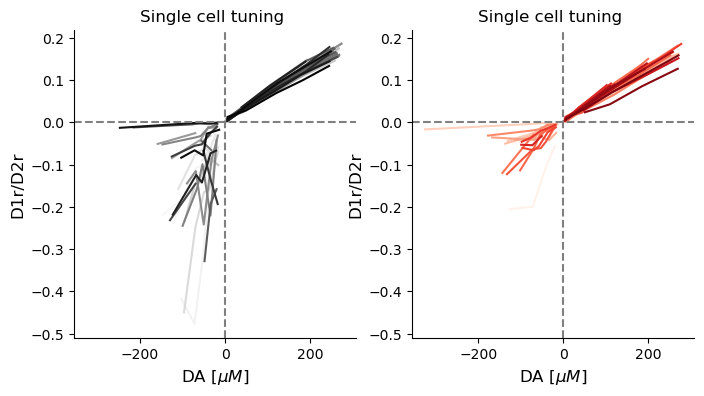

In [20]:

n_bins= 5
da_pos_cells = np.zeros((2,45,n_bins))
da_neg_cells = np.zeros((2,45,n_bins))
rec_d1_cells = np.zeros((2,45,n_bins))
rec_d2_cells = np.zeros((2,45,n_bins))
id_x_var=1
bins_pos  = np.linspace(10,300,n_bins)
bins_neg  = np.linspace(-80,-10,n_bins)
for i_group in  np.arange(2):
    tr_var_cells =trial_var_cells.copy()
    per_cell = tr_var_cells[i_group,1,i_win_us,:,:,:]
    base_cells = tr_var_cells[i_group,1,i_win_base,:,:,:] 
    rec_d1 = tr_var_cells[i_group,2,i_win_us,:,:,:]
    base_d1 = tr_var_cells[i_group,2,i_win_base,:,:,:]
    rec_d2 =  tr_var_cells[i_group,3,i_win_us,:,:,:]
    base_d2 = tr_var_cells[i_group,3,i_win_base,:,:,:]
    d_da = per_cell - base_cells
    d_d1 = rec_d1 - base_d1
    d_d2 = rec_d2 - base_d2

    for i_cell in  range(per_cell.shape[0]):
        mu_da = d_da[i_cell,:,:]
        mu_rec_d1 = d_d1[i_cell,:,:]
        mu_rec_d2 = d_d2[i_cell,:,:]
        utility_axis = np.nanmean(mu_da,axis=1)
        zcr_da = utils.compute_zero_crossings(mu_da,utility_axis,1, method_zcross) 
        zcr_i = np.floor(np.interp(zcr_da[0][0],utility_axis,np.arange(6)))  
        if not np.isnan(zcr_i):
            da_pos,da_neg,rec_pos,rec_neg = utils.get_pos_neg_regime_variables(zcr_i,mu_da,mu_rec_d1,mu_rec_d2,truncate_reg=True)
            da_pos_cells[i_group,i_cell,:], rec_d1_cells[i_group,i_cell,:] = digitize_responses(da_pos, rec_pos,bins_pos)
            da_neg_cells[i_group,i_cell,:], rec_d2_cells[i_group,i_cell,:]  =digitize_responses(da_neg, rec_neg,bins_neg)


# Lesion has less neurons, take out zero: 
da_pos_cells[da_pos_cells==0]=np.nan
da_neg_cells[da_neg_cells==0]=np.nan
rec_d1_cells[rec_d1_cells==0]=np.nan
rec_d2_cells[rec_d2_cells==0]=np.nan

# Single cell tuning:  mean across neurns
fig,ax = plt.subplots(figsize=(6,4))
[ax.errorbar(np.nanmean(da_pos_cells[ig,:,:],axis=0),np.nanmean(rec_d1_cells[ig,:,:],axis=0),
          np.nanstd(rec_d1_cells[ig,:,:],axis=0)/np.sqrt(n_cells),color=colors_g[ig]) for ig in range(2)]
[ax.errorbar(np.nanmean(da_neg_cells[ig,:,:],axis=0),np.nanmean(rec_d2_cells[ig,:,:],axis=0),
          np.nanstd(rec_d2_cells[ig,:,:],axis=0)/np.sqrt(n_cells),color=colors_g[ig]) for ig in range(2)]
plot_config(ax,r'DA [$\mu M$]','D1r/D2r',12, False)
title_(ax,'Single cell tuning - mean across cells')

# Single cell tuning:  plot single neurns
cmaps = [cm.Greys,cm.Reds]
fig,ax = plt.subplots(1,2,figsize=(8,4))
_ = [[ax[ig].plot(da_pos_cells[ig,icell,:],rec_d1_cells[ig,icell,:],color=cmaps[ig](icell/n_cells)) for icell in range(n_cells)] for ig in range(2)]
_ = [[ax[ig].plot(da_neg_cells[ig,icell,:],rec_d2_cells[ig,icell,:],color=cmaps[ig](icell/n_cells)) for icell in range(n_cells)] for ig in range(2)]
[title_(ia,'Single cell tuning ') for ia in ax]
xl = limit_xaxis(ax)
yl = limit_yaxis(ax)
[ia.plot([np.min(xl),np.max(xl)],[0,0],'--',color='grey') for ia in ax]
[ia.plot([0,0],[np.min(yl),np.max(yl)],'--',color='grey') for ia in ax]
[plot_config(ia,r'DA [$\mu M$]','D1r/D2r',12, False) for ia in ax]

# 1. Create two figure wrappers

fig_mean_tuning = FigureWithData(fig)    # Mean across cells plot
fig_single_cells = FigureWithData(fig)   # Single-cell scatter plot

# 2. Save the individual digitized cell data (per group)
n_cells = da_pos_cells.shape[1]

# Flatten across cells and bins
for ig in range(2):  # 0: Control, 1: Learning
    # Positive DA regime
    data_pos = np.column_stack((
        np.tile(np.arange(n_bins), n_cells),
        da_pos_cells[ig, :, :].flatten(),
        rec_d1_cells[ig, :, :].flatten()
    ))
    fig_single_cells.add_data(
        f"Single cell tuning (positive regime) - group {groups[ig]}",
        data_pos,
        ['Bin_index', 'DA_bin_value', 'D1R_response']
    )
    
    # Negative DA regime
    data_neg = np.column_stack((
        np.tile(np.arange(n_bins), n_cells),
        da_neg_cells[ig, :, :].flatten(),
        rec_d2_cells[ig, :, :].flatten()
    ))
    fig_single_cells.add_data(
        f"Single cell tuning (negative regime) - group {groups[ig]}",
        data_neg,
        ['Bin_index', 'DA_bin_value', 'D2R_response']
    )

# 3. Save the mean tuning curves across neurons

for ig in range(2):
    # Positive regime (mean ± sem)
    mean_pos = np.nanmean(rec_d1_cells[ig, :, :], axis=0)
    sem_pos = np.nanstd(rec_d1_cells[ig, :, :], axis=0) / np.sqrt(n_cells)
    da_mean_pos = np.nanmean(da_pos_cells[ig, :, :], axis=0)
    
    mean_data_pos = np.column_stack((
        da_mean_pos,
        mean_pos,
        sem_pos
    ))
    fig_mean_tuning.add_data(
        f"Mean tuning (positive regime) - group {groups[ig]}",
        mean_data_pos,
        ['Mean_DA_bin', 'Mean_D1R_response', 'SEM_D1R_response']
    )

    # Negative regime (mean ± sem)
    mean_neg = np.nanmean(rec_d2_cells[ig, :, :], axis=0)
    sem_neg = np.nanstd(rec_d2_cells[ig, :, :], axis=0) / np.sqrt(n_cells)
    da_mean_neg = np.nanmean(da_neg_cells[ig, :, :], axis=0)
    
    mean_data_neg = np.column_stack((
        da_mean_neg,
        mean_neg,
        sem_neg
    ))
    fig_mean_tuning.add_data(
        f"Mean tuning (negative regime) - group {groups[ig]}",
        mean_data_neg,
        ['Mean_DA_bin', 'Mean_D2R_response', 'SEM_D2R_response']
    )

# 4. Save everything
fig_mean_tuning.save(
    base_filename='figure_7c_mean_tuning',
    folder_data=data_fig_dir,
    folder_figures=fig_dir
)

fig_single_cells.save(
    base_filename='figure_7c_single_cell_tuning',
    folder_data=data_fig_dir,
    folder_figures=fig_dir
)



**Compute $\tau$ with the mean response across population**


Similar process as above :

1. Select independent variable = Input firing rate (id = 0), DA concentration (id = 1) in `id_vars_x`
2. Select dependent variables = D1 occupancy for positive responses, D2 occupancy for negative responses
   
      Select the epoch responses at US and at baseline for each variable and perform baseline subtraction

3. Chose a random set of trials and neurons per iteration
4. Compute **utility axis** based on the mean across neurons and trials for the indpendent variable
5. Compute the **zero crossing points** based on the mean across neurons
6. Compute the **asymmetric learning rates** ($\alpha_i^+$,$\alpha_i^-$) based on the mean across neurons using the zero crossing point from step (5). 
7. Compute the **asymmetric scaling factor** ($\tau_i = \frac{\alpha_i^+}{\alpha_i^+ + \alpha_i^-}$) 

Perform the steps (1-7) for 100 iterations (`niterations`)

Output variable:

- `taus_lin_pop`: distribution of $tau$ across iterations randomly sampling from trials and neurons (N groups x N iterations)

In [21]:
#% % Eta at population  level : 
niterations = 100
n_pseudo_trials= 300
n_cells = 45
i_win_base = 2
i_win_us = 1
iio  = 0
method_regress = 'siegelslopes'
method_zcross = 'count'
taus_lin_pop = np.zeros((2,niterations))

for i_group in np.arange(2):
    tr_var_cells = trial_var_cells.copy()
    base_cells = tr_var_cells[i_group,1,i_win_base,:,:,:]
    per_cell = tr_var_cells[i_group,1,i_win_us,:,:,:]
    per_cell = per_cell-base_cells
    utility_axis =np.nanmean(np.nanmean(per_cell,axis=2),axis=0)
    da_us =  tr_var_cells[i_group,1,i_win_us,:,:,:]
    rec_occ_pos =  tr_var_cells[i_group,2,i_win_us,:,:,:]
    rec_occ_neg = tr_var_cells[i_group,3,i_win_us,:,:,:]
    da_base = tr_var_cells[i_group,1,i_win_base,:,:,:]
    occ_base_pos = tr_var_cells[i_group,2,i_win_base,:,:,:]
    occ_base_neg = tr_var_cells[i_group,3,i_win_base,:,:,:]
    (da_us,rec_occ_pos,rec_occ_neg,da_base,occ_base_pos,occ_base_neg) = [replace_zeros_to_nan(var) for var in [da_us,rec_occ_pos,rec_occ_neg,da_base,occ_base_pos,occ_base_neg]]
    notnan = np.argwhere(~np.isnan(per_cell))
    trial_max = np.max(notnan[:,2])
    id_cells = [np.random.choice(np.arange(per_cell.shape[0]),per_cell.shape[0]) for _ in range(niterations)]
    id_trials = [np.random.choice(np.arange(trial_max),n_pseudo_trials) for _ in range(niterations)]
    utility_axis = [np.floor(np.nanmean(np.nanmean(per_cell[ids,:,:][:,:,idt],axis=2),axis=0)*1000)/1000  for (idt,ids) in zip(id_trials,id_cells)]
    zcr = [utils.compute_zero_crossings(np.nanmean(per_cell[ids,:,:][:,:,idt],axis=0),uaxis,1,method_zcross)[0][0] for (idt,ids,uaxis) in zip(id_trials,id_cells,utility_axis)]
    zcr_i = [np.round(np.interp(zcri,uaxis,np.arange(6)))  for (uaxis,zcri) in zip(utility_axis,zcr)]
    id_neg = [np.int0(np.arange(zcri)) for zcri in zcr_i]
    id_pos = [np.int0(np.arange(zcri,6)) for zcri in zcr_i]
    xx_pos = [np.nanmean(da_us[ids,:,:][:,:,idt]-da_base[ids,:,:][:,:,idt],axis=0)[ipos].flatten() for (idt,ids,ipos) in zip(id_trials,id_cells,id_pos)]
    yy_pos = [np.nanmean(rec_occ_pos[ids,:,:][:,:,idt]-occ_base_pos[ids,:,:][:,:,idt],axis=0)[ipos].flatten() for (idt,ids,ipos) in zip(id_trials,id_cells,id_pos)]
    xx_neg= [np.nanmean(da_us[ids,:,:][:,:,idt]-da_base[ids,:,:][:,:,idt],axis=0)[ineg].flatten() for (idt,ids,ineg) in zip(id_trials,id_cells,id_neg)]
    yy_neg = [np.nanmean(rec_occ_neg[ids,:,:][:,:,idt]-occ_base_neg[ids,:,:][:,:,idt],axis=0)[ineg].flatten() for (idt,ids,ineg) in zip(id_trials,id_cells,id_neg)]
    m = [utils.compute_asymmetric_scaling_receptor(xxp,xxp_l,yyp,xxn,xxn_l,yyn_neg,method_regress=method_regress) for (xxp,xxp_l,yyp,xxn,xxn_l,yyn_neg) in zip(xx_pos,xx_pos,yy_pos,xx_neg,xx_neg,yy_neg)]
    taus_lin_= np.asarray([im[1] for im in m])
    taus_lin_pop[i_group,:] = taus_lin_

## Figure 7d

**Plot of distributions of $\tau$ across iterations**

The null hypothesis can be rejected: not drawn from a normal distribution
Saved figure to figures/figure_7/figure_7d_population_tau.pdf
Saved data and stats to data/source_data/figure_7/figure_7d_population_tau.txt


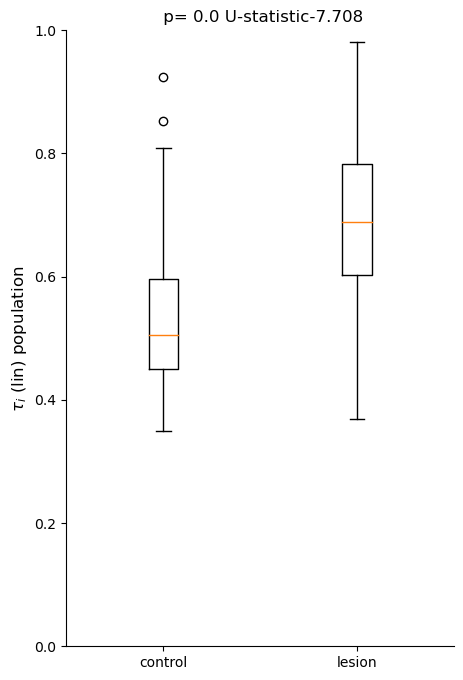

In [ ]:
#% % Box plot for populatiob taus:
alternative = 'less'
to_test = [taus_lin_pop]
name_preffs= ['tau_lin_pop']
tit_suff = ['lin']
name_suff = 'd'
for (taus_pop,name_preff,itit) in zip(to_test,name_preffs,tit_suff):
    fig,ax = plt.subplots(figsize=(5,8))
    taulist = [taus_pop[ig,:][(taus_pop[ig,:]<1)*(taus_pop[ig,:]>0)] for ig in range(2)]
    ax.boxplot(taulist)  
    tests_pd = get_tests_table([taulist], name_preff, name_suff,alternative=alternative,tests_pd=tests_pd)
    gnames =name_preff+ '_'+name_suff
    ll = len(tests_pd[(tests_pd['name_test'] == 'normaltest') & (tests_pd['group_name'] == name_preff +'_all')].pvals.to_numpy()[0])
    ss = np.sum(tests_pd[(tests_pd['name_test'] == 'normaltest') & (tests_pd['group_name'] ==name_preff +'_all')].pvals.to_numpy()[0]>.05)
    if ll>ss:
        pvals = tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_name'] == gnames)].pvals.to_numpy()[0]
        stats_p = tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_name'] == gnames)].stats.to_numpy()[0]  
        stats_n = tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_name'] == gnames)].stat_name.to_numpy()[0]  
        test_n = 'ranksum'
    else:
        pvals = tests_pd[(tests_pd['name_test'] == 'ttest') & (tests_pd['group_name'] ==gnames)].pvals.to_numpy()[0]
        stats_p = tests_pd[(tests_pd['name_test'] == 'ttest') & (tests_pd['group_name'] == gnames)].stats.to_numpy()[0]   
        stats_n = tests_pd[(tests_pd['name_test'] == 'ttest') & (tests_pd['group_name'] == gnames)].stat_name.to_numpy()[0]  
        test_n = 't-test'  
    ax.set_title(' p= '+str(np.floor(pvals*10000)/10000) + ' '+stats_n+ str(np.floor(stats_p*1000)/1000) ) 
    plot_config(ax,'',r'$\tau_i$ ('+itit+') population',12,False) 
    ax.set_xticklabels( groups)
    ax.set_ylim([.0,1]) 

    # 1. Create the wrapper
    fig_data_tau_pop = FigureWithData(fig)

    # 2. Save tau values for both groups
    # (You already selected the valid taus between 0 and 1)
    taulist = [taus_pop[ig, :][(taus_pop[ig, :] < 1) * (taus_pop[ig, :] > 0)] for ig in range(2)]

    # Pad shorter group with NaN if needed
    max_len = max(len(taulist[0]), len(taulist[1]))
    taus_padded = np.full((max_len, 2), np.nan)
    taus_padded[:len(taulist[0]), 0] = taulist[0]
    taus_padded[:len(taulist[1]), 1] = taulist[1]

    fig_data_tau_pop.add_data(
        "Population taus per group",
        taus_padded,
        ['Tau_Control', 'Tau_Lesion']
    )

    # 3. Save the statistical test result
    # (Already computed: pvals, stats_p, stats_n, test_n)

    stat_array = np.array([[pvals, stats_p]])
    stat_headers = ['p_value', 'test_statistic']

    fig_data_tau_pop.add_stats(
        f"Statistical test ({test_n}, {stats_n})",
        stat_array,
        stat_headers
    )

    # 4. Save everything
    fig_data_tau_pop.save(
        base_filename='figure_7d_population_tau',
        folder_data= data_fig_dir,
        folder_figures= fig_dir
    )




## Figure 7f

## Reinforcement learning (DRL) simulations 

This notebook performs RL simulations of the Pavlovian task from Tian & Uchida, 2015, using data-derived parameters:

- $\tau s $ derived from dopamine firing rates from Lhb lesion dataset
- $\eta $ derived from biophysical simulations (correspond to the asymmetric scaling factor given by receptor sensitivities, computed at a population level in **Figure 6i**)
- $\beta$ correspons to the decay factor in the updates for the $P$ and $N$ variables

Types of simulations  (`simulation_type`) are {`eta_sampling_`, `eta_nosampling_nodistr_`, `eta_nosampling_nodistr_`}


`eta_sampling_`: TD learning with DRL performing sampling for the computation of next step value predictors. 
$$
\delta_{i,t} = r_t + \gamma \cdot \hat{z}(s_{t+1}) - V_i(s_t)\\
\hat{\delta}_{i,t} ~~ = ~~~\tau_i \cdot \delta_{i,t} ~~~... ~~~\text{if} ~ \delta_{i,t} >0 \\
\hat{\delta}_{i,t}  = (1-\tau_i) \cdot \delta_{i,t} ~~~... ~~~\text{if} ~ \delta_{i,t} \leq 0
$$

- Where $ \hat{z}(s_{t+1})$ is a sample from the distribution defined by the set of $\hat{V}_i(s_{t+1})$
- Update of value:
$$
P_i(s_t) \leftarrow P_i(s_t) + \eta \cdot |\hat{\delta}_i(t)| - \beta \cdot P_i(s_t) ~~~... ~~~\text{if} ~ \delta_{i,t} >0\\
N_i(s_t) \leftarrow N_i(s_t) + (1-\eta) \cdot |\hat{\delta}_i(t)| - \beta \cdot N_i(s_t) ~~~... ~~~\text{if} ~ \delta_{i,t} \leq 0 \\
\hat{V}_i(s_t) = P_i(s_t) - N_i(s_t)
$$  

`eta_nosampling_nodistr_`: TD learning not DRL using the mean across  $\tau s $  
$$
\delta_{t} = r_t + \gamma \cdot V(s_{t+1}) - V(s_t)\\
\hat{\delta}_{t} ~~ = ~~~\hat{\tau} \cdot \delta_{t} ~~~... ~~~\text{if} ~ \delta_{t} >0 \\
\hat{\delta}_{t}  =(1-\hat{\tau}) \cdot \delta_{t} ~~~... ~~~\text{if} ~ \delta_{t} \leq 0
$$

- Where $ \hat{\tau}$ is the mean of the $\tau_i$ across the population of each group
- Update of value:
$$
P(s_t) \leftarrow P(s_t) + \eta \cdot |\hat{\delta}_i(t)| - \beta \cdot P(s_t) ~~~... ~~~\text{if} ~ \delta_{t} >0\\
N(s_t) \leftarrow N(s_t) + (1-\eta) \cdot |\hat{\delta}_i(t)| - \beta \cdot N(s_t) ~~~... ~~~\text{if} ~ \delta_{t} \leq 0 \\
\hat{V}(s_t) = P(s_t) - N(s_t)
$$  


`eta_nosampling_nodistr_`: TD learning with DRL without performing sampling for the computation of next step value predictors
$$
\delta_{i,t} = r_t + \gamma \cdot \hat{V}_i(s_{t+1}) - V_i(s_t)\\
\hat{\delta}_{i,t} ~~ = ~~~\tau_i \cdot \delta_{i,t} ~~~... ~~~\text{if} ~ \delta_{i,t} >0 \\
\hat{\delta}_{i,t}  = (1-\tau_i) \cdot \delta_{i,t} ~~~... ~~~\text{if} ~ \delta_{i,t} \leq 0
$$

- Where $ \hat{V}_i(s_{t+1})$  is the value predictor in the next time step
- Update of value:
$$
P_i(s_t) \leftarrow P_i(s_t) + \eta \cdot |\hat{\delta}_i(t)| - \beta \cdot P_i(s_t) ~~~... ~~~\text{if} ~ \delta_{i,t} >0\\
N_i(s_t) \leftarrow N_i(s_t) + (1-\eta) \cdot |\hat{\delta}_i(t)| - \beta \cdot N_i(s_t) ~~~... ~~~\text{if} ~ \delta_{i,t} \leq 0 \\
\hat{V}_i(s_t) = P_i(s_t) - N_i(s_t)
$$ 

**Note**: To plot and use the present notebook the user needs to download the data inside `analysis` folder of the OSF repository. Look at  `download_data` for the code to do this.

In [23]:

save_dir = 'data/analysis'
if not os.path.isdir(save_dir):
    os.makedirs(save_dir)


g_names = ['control','lesion']
i
taus_dic=np.load( os.path.join(save_dir,'taus_rec_occ_vs_da_level_population.npz'),allow_pickle=True )
taus_lin = taus_dic['taus_lin']
taus_lin[taus_lin>1] =np.nan

taus_dic_data=np.load(os.path.join(save_dir,'drl_metrics_from_data.npz'),allow_pickle=True )
taus_c = taus_dic_data['tau_control']
taus_l = taus_dic_data['tau_lesion']
taus_g = [taus_c,taus_l]




In [24]:
simulations_dir = os.path.join('data','local','analysis','rl_simulations')

simulation_type = 'eta_nosampling_nodistr_' 
beta_v = [0.001,0.002,0.005,0.01,0.015,0.02] 
for ieps in np.arange(len(beta_v)):
    epsilon_ = beta_v[ieps]
    for i_group in  np.arange(2):
        results_v = list()
        etas = taus_lin[i_group,:]        
        n_iterations = 25 
        taus_= np.sort(taus_g[i_group])
        taus_ = taus_[(taus_>0)*(taus_<1)]
        #% %
        for ie in np.arange(n_iterations):
            if not  np.isnan(etas[ie] ):
                s = dict()
                s['agent'] = dict()
                s['task'] = dict()
                if simulation_type == 'eta_nosampling_' :
                    s['agent']['taus'] =  np.sort(taus_) # needs to be array  np.asarray([np.nanmean(taus_) ]) #  np.sort(taus_)
                    s['agent']['do_sampling'] = False
                elif simulation_type == 'eta_nosampling_nodistr_': 
                    s['agent']['taus'] =   np.asarray([np.nanmean(taus_) ]) # needs to be array 
                    s['agent']['do_sampling'] = False
                elif simulation_type == 'eta_sampling_': 
                    s['agent']['taus'] =  np.sort(taus_) # needs to be array  np.asarray([np.nanmean(taus_) ]) #  np.sort(taus_)
                    s['agent']['do_sampling'] = True

                s['agent']['eta'] = etas[ie]
                print('Processing for eta = '+ str(etas[ie]) + 'epsilon = '+str(epsilon_) + '|| ' +str(ie) + ' of '+str(n_iterations))
                s['agent']['str_agent'] = ['Eta_' + str(etas[ie])]#,'neutral','optimistic']
                s['agent']['epsilon'] = epsilon_
                s['agent']['base_alpha'] = 1 
                s['agent']['gamma'] = 0.99
                
                s['agent']['d1_d2'] = True
                s['task']['prob'] = [[.1, .9],[.5, .5],[.9, .1] ,[.8, .2]]
                s['task']['mags'] = [[1, 0],[1, 0],[1, 0] ,[-1, 0]]
                s['task']['percent_per_cs'] = 1/len(s['task']['mags'])*np.ones((len(s['task']['mags']),1))
                s['task']['cs_id'] = [[0,0],[1,1],[2,2],[3,3]]
                s['task']['str_cs'] = [ '10%','50%','90%','80%Puff']
                s['task']['str_task'] = 'drl_6odor'
                s['task']['n_trials'] = 2000
                s['task']['cue_onset'] = 1
                s['task']['cue_dur'] = 1
                s['task']['rew_onset'] = 3
                s['task']['iti_dur'] = 1
                s['task']['n_iterations'] = 1
                s['task']['seed']=seed_value
                s['task']['type'] = 'cue_reward'

                agent = TDLearning(s)
                agent.initialize_results()
                agent.run_task()
                agent.reformat_results()
                save_dic = dict()
                results = dict()
                save_vars = ['distribution_trials_full', 'distribution_g_trials_full', 'distribution_ng_trials_full',  'deltas_trials_full', 
                             'distribution_ng_trials', 'distribution_g_trials', 'distribution_trials','deltas_trials']
                for ivar in save_vars:
                    temp = agent.results[ivar]
                    if len(temp.shape)==4:
                        id_end = np.argwhere(np.nansum(temp,axis=(0,1,2))==0).flatten()[0]
                        temp = temp[:,:,:,:id_end]
                    results[ivar] = temp
                save_vars = ['distribution','distribution_g','distribution_ng','samp_distribution','deltas','deltas_trials_raw','distribution_std']
                new_dict = vars(agent)
                for ivar in save_vars:
                    results[ivar] = new_dict[ivar]
                agent_dict = dict()
                save_vars=['taus', 'eta', 'str_agent', 'epsilon', 'base_alpha', 'do_sampling', 'gamma',
                            'n_cells', 'task_type', 'n_deliv_rew', 'deliv_rew', 'deliv_cs', 'trial_length', 
                            'n_trials', 'cs_vector', 'us_vector', 'id_states_per_cs', 'n_types', 'n_tr_max', 
                            'i_step_per_cs']
                for ivar in save_vars:
                    agent_dict[ivar] = new_dict[ivar]
                save_dic['results'] = results
                save_dic['agent'] = agent_dict
                save_dic['task'] = vars(agent.task)
                save_dic['eta'] = etas
                np.save(os.path.join(simulations_dir,'results_sim_type_'+ simulation_type 
                + 'eps_' + str(epsilon_).replace('.','_')+'_'+g_names[i_group]+'_iteration_'+str(ie) ),save_dic)
                print('Saving ' + simulations_dir,'results_sim_type_'+simulation_type 
                + 'eps_' + str(epsilon_).replace('.','_')+'_'+g_names[i_group]+'_iteration_'+str(ie) )

Processing for eta = 0.5485640794749749epsilon = 0.001|| 0 of 25
Saving data/local/analysis/rl_simulations results_sim_type_eta_nosampling_nodistr_eps_0_001_control_iteration_0
Processing for eta = 0.49892232744640674epsilon = 0.001|| 1 of 25
Saving data/local/analysis/rl_simulations results_sim_type_eta_nosampling_nodistr_eps_0_001_control_iteration_1
Processing for eta = 0.6476778171616318epsilon = 0.001|| 2 of 25
Saving data/local/analysis/rl_simulations results_sim_type_eta_nosampling_nodistr_eps_0_001_control_iteration_2
Processing for eta = 0.5527251415337265epsilon = 0.001|| 3 of 25
Saving data/local/analysis/rl_simulations results_sim_type_eta_nosampling_nodistr_eps_0_001_control_iteration_3
Processing for eta = 0.3651013251178255epsilon = 0.001|| 4 of 25
Saving data/local/analysis/rl_simulations results_sim_type_eta_nosampling_nodistr_eps_0_001_control_iteration_4
Processing for eta = 0.5084845236614342epsilon = 0.001|| 6 of 25
Saving data/local/analysis/rl_simulations results

The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis cannot be rejected
The null hypothesis cannot be rejected
The null hypothesis cannot be rejected
The null hypothesis cannot be rejected
The null hypothesis cannot be rejected
Saved figure to figures/figure_7/figure_7f_beta_0.001.pdf
Saved figure to figures/figure_7/figure_7g_beta_0.001.pdf
The null hypothesis cannot be rejected
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis cannot be rejected
The null hypothesis cannot be rejected
The null hypothesis cannot be rejected
The null hypothesis cannot be rejected
The null hypothesis cannot be rejected
Saved figur

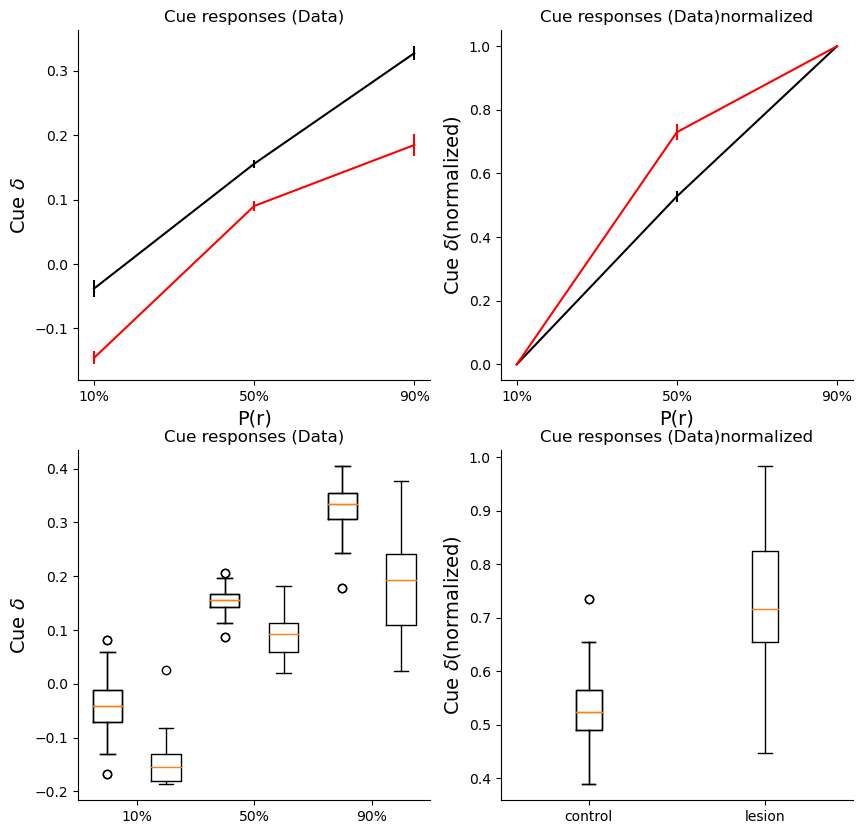

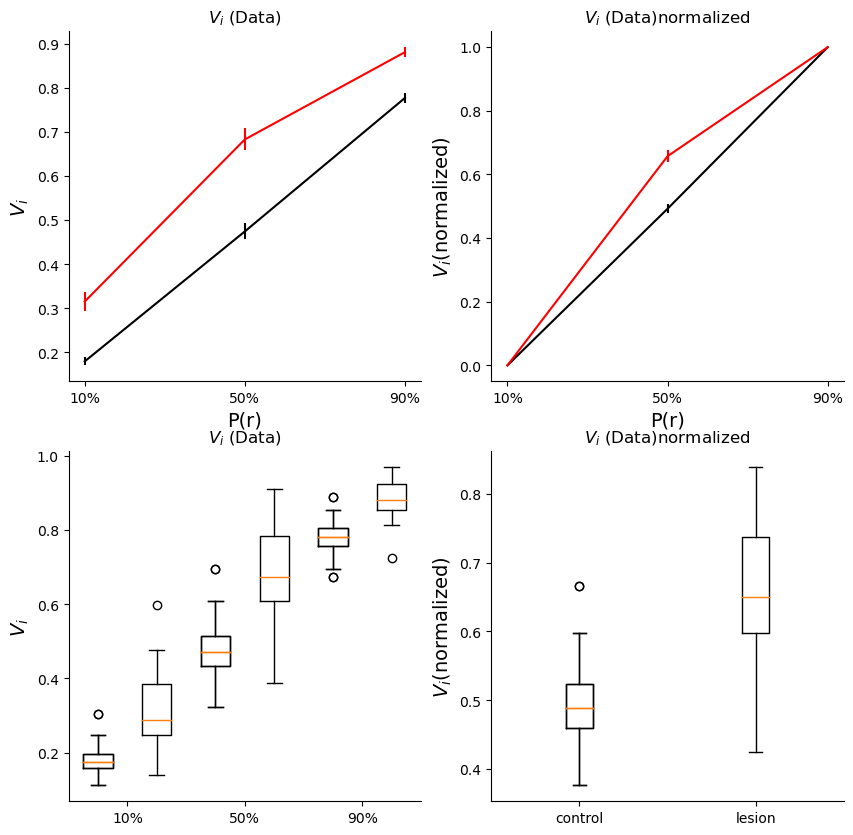

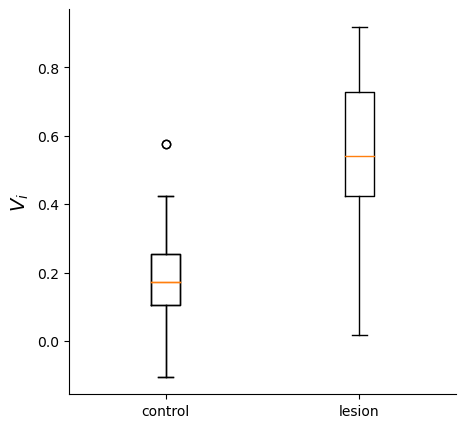

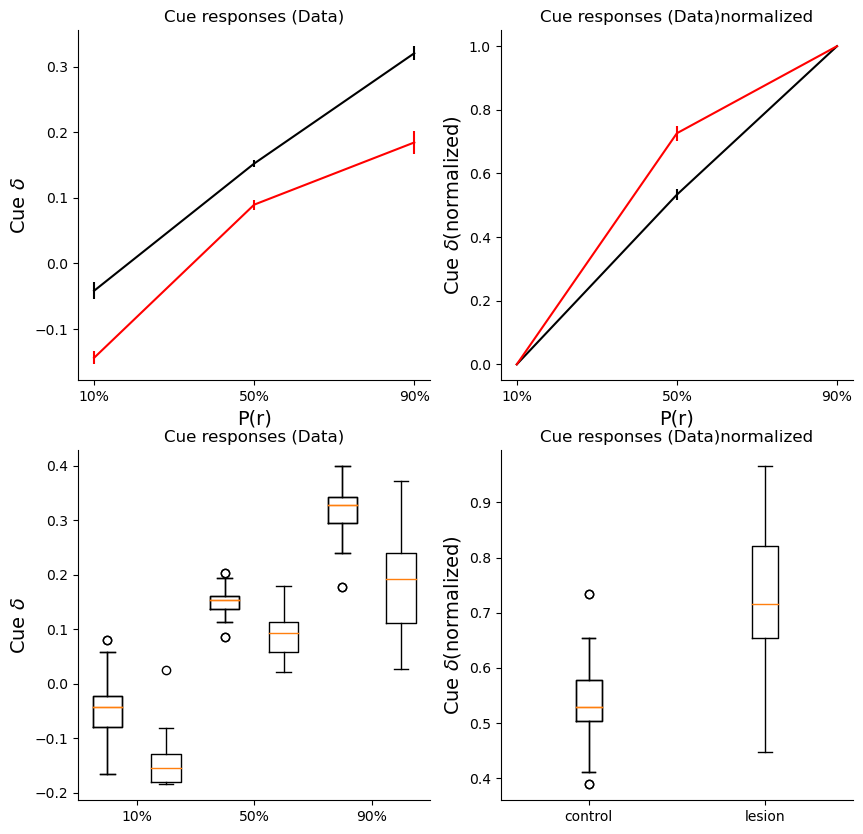

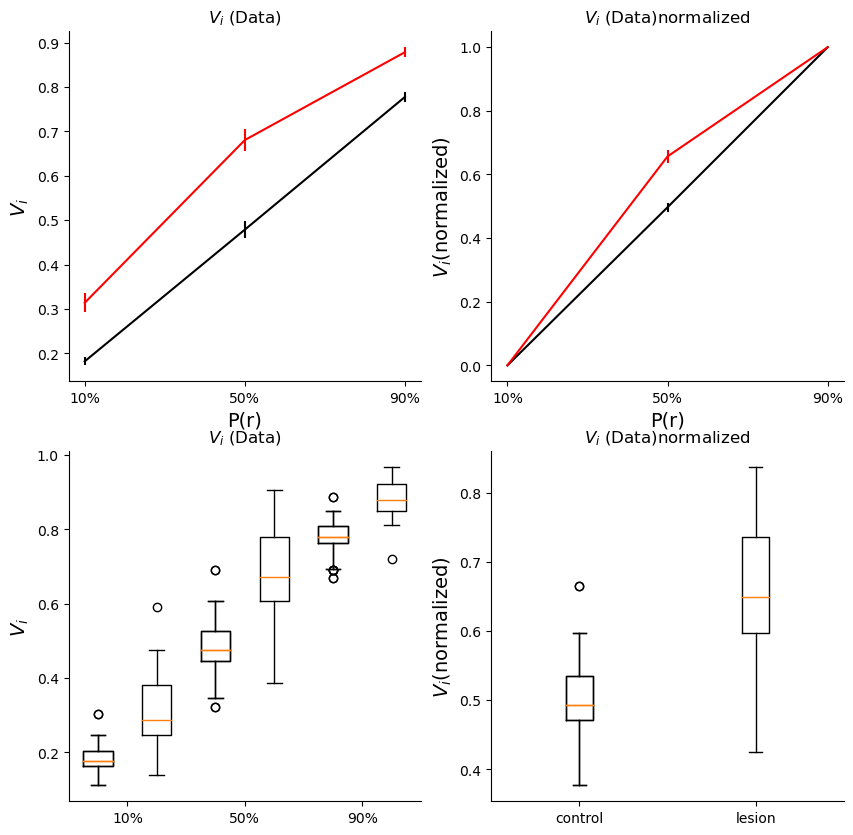

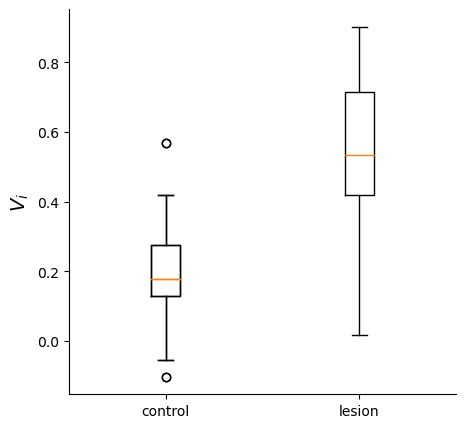

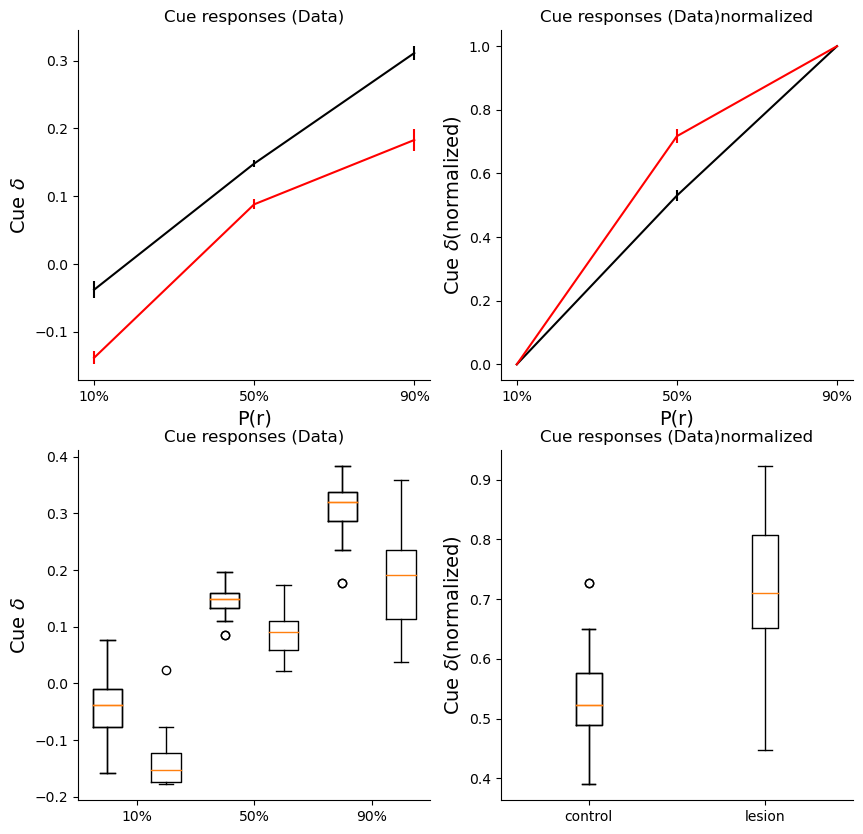

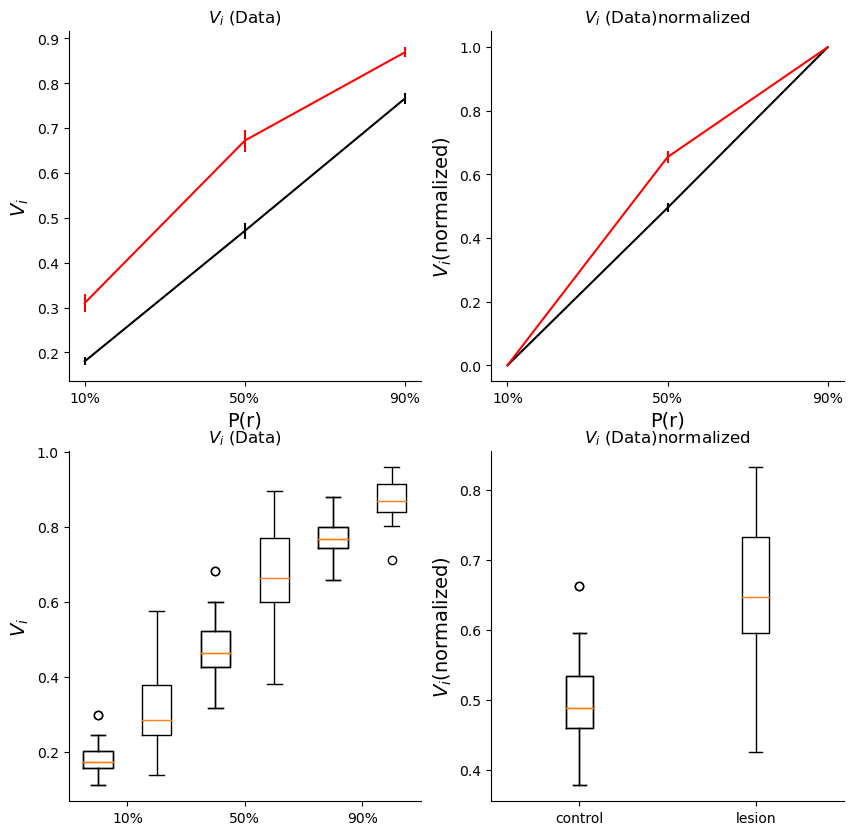

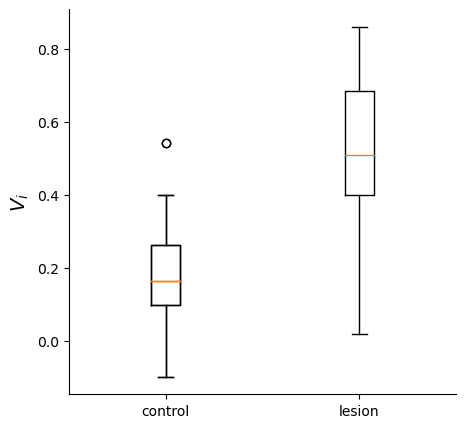

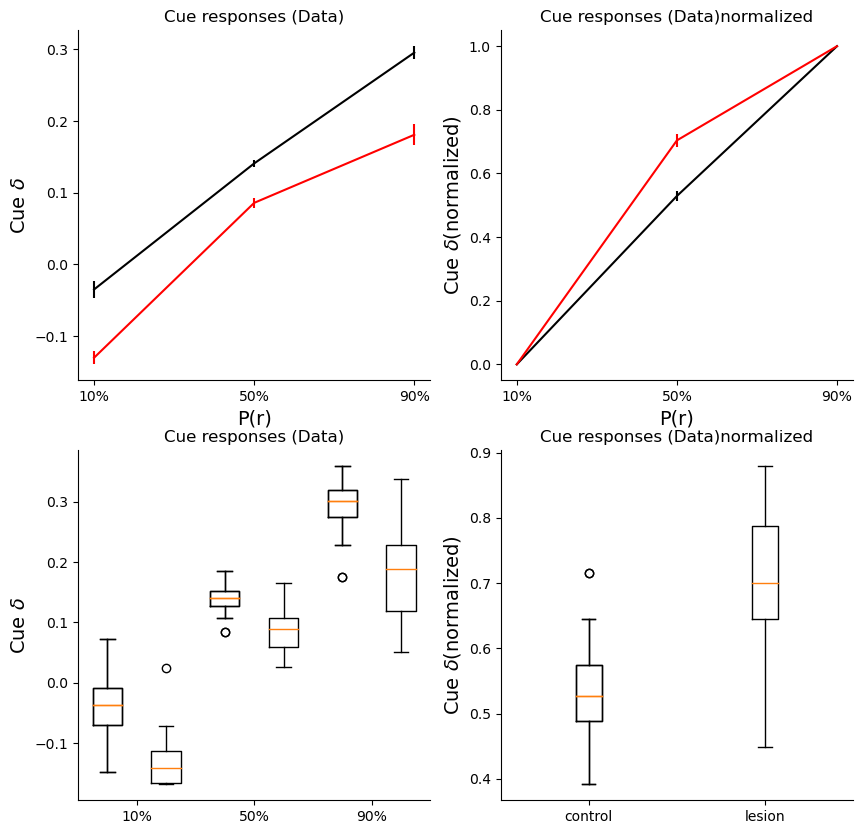

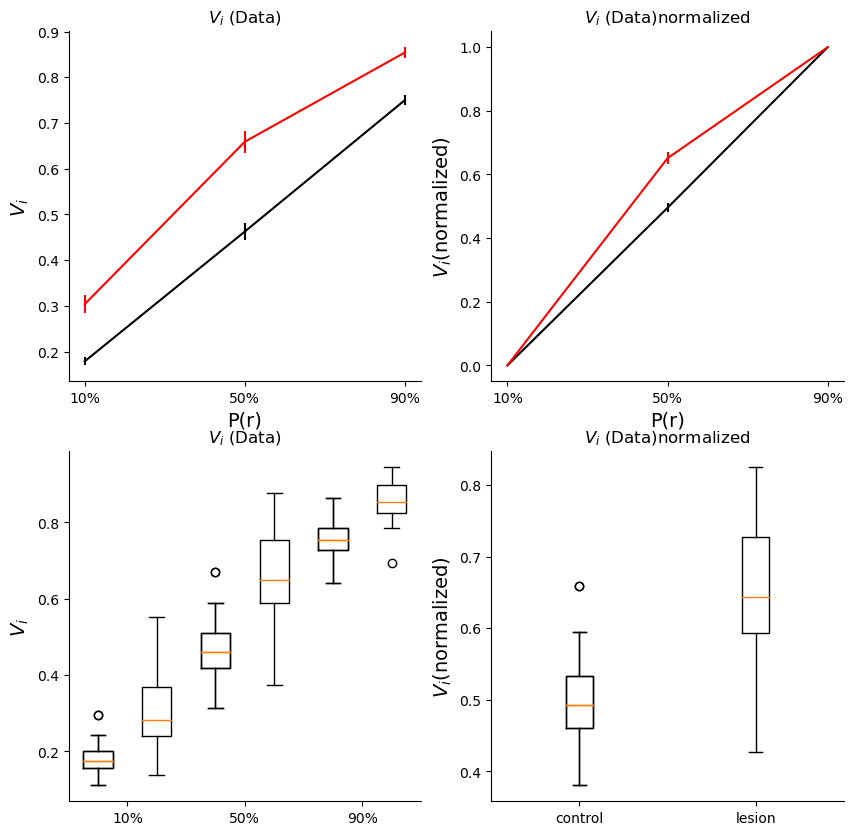

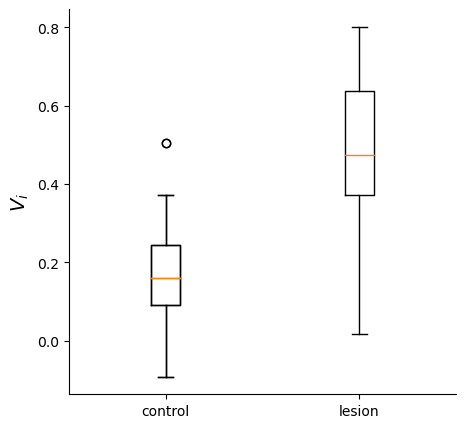

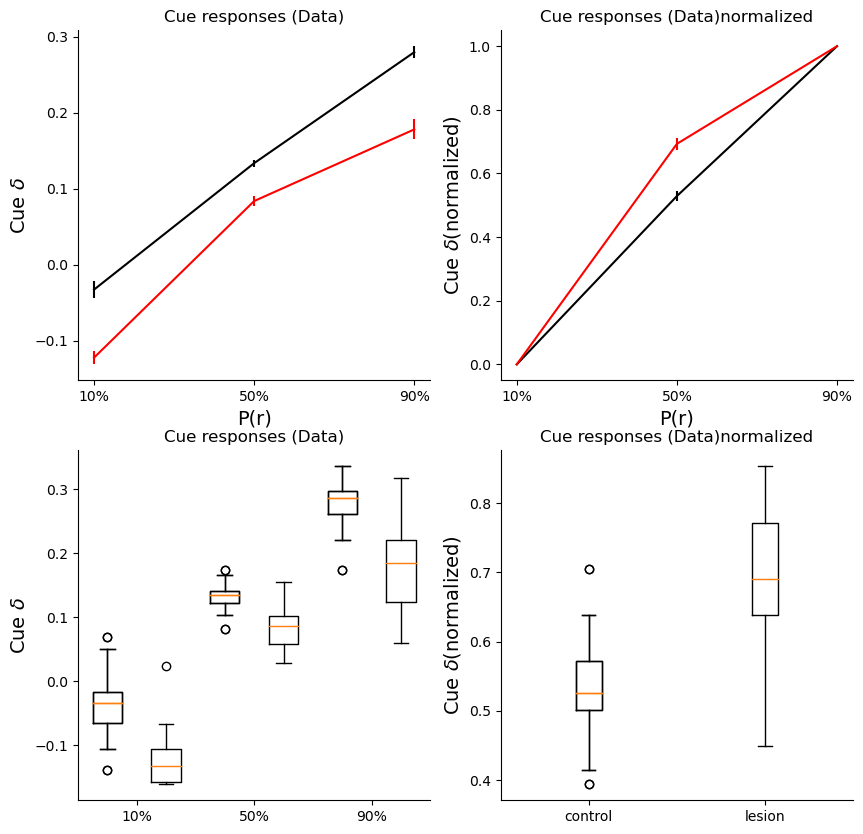

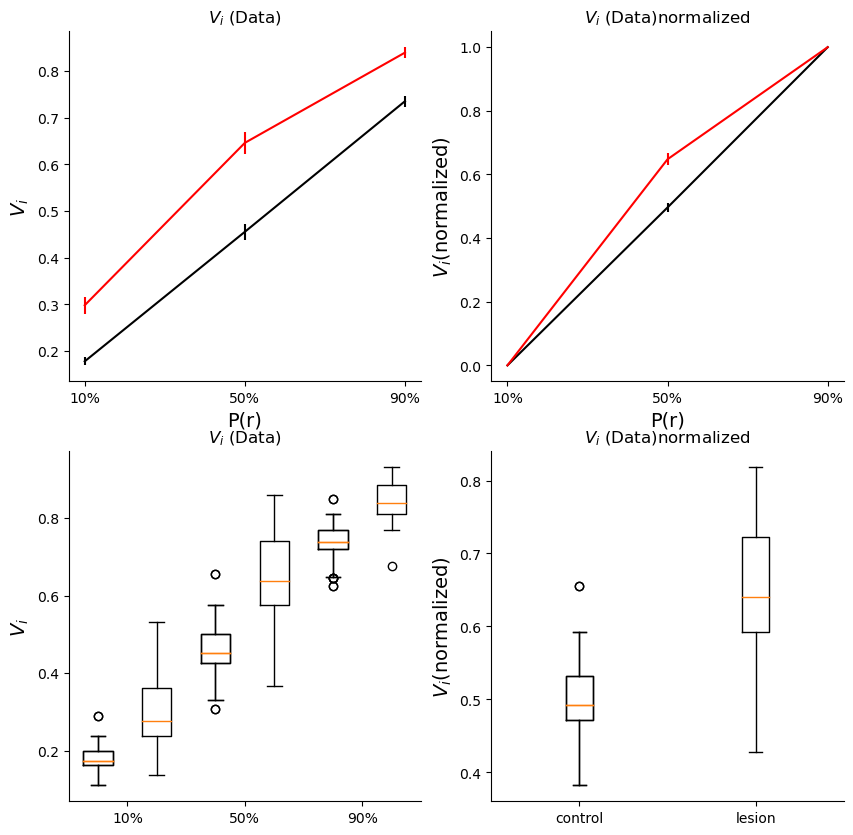

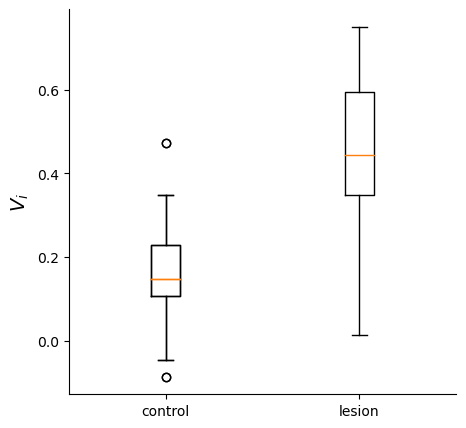

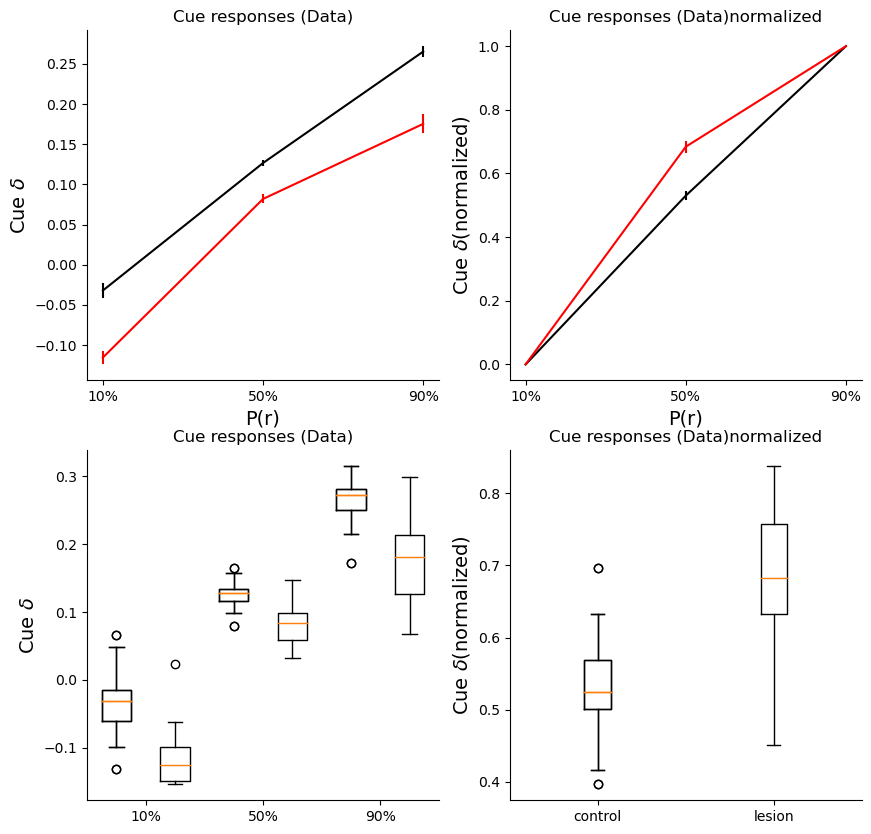

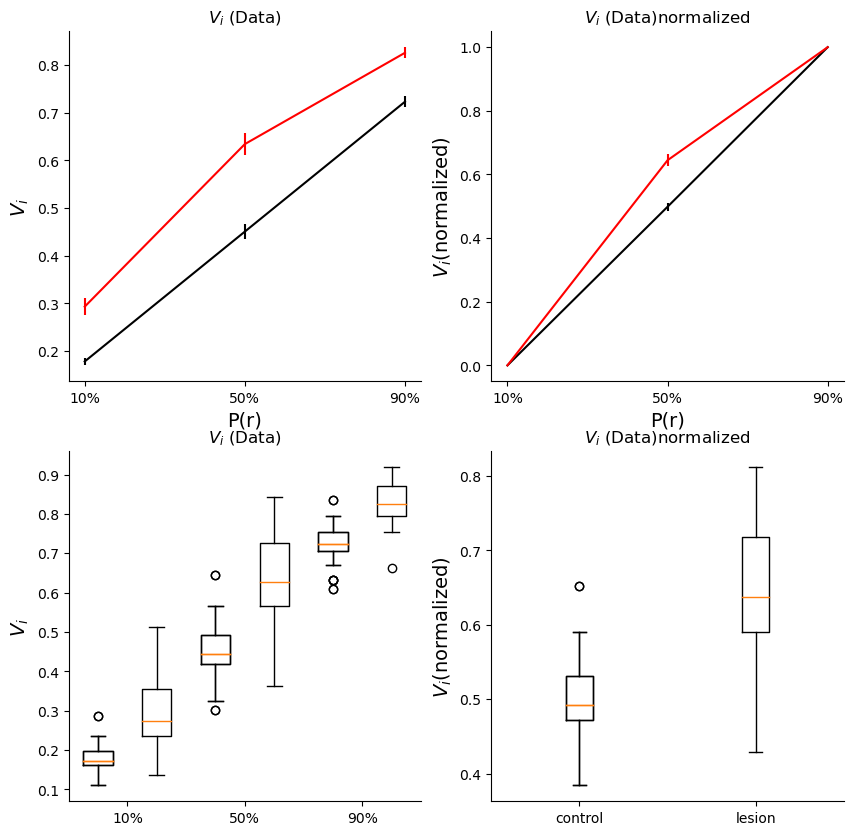

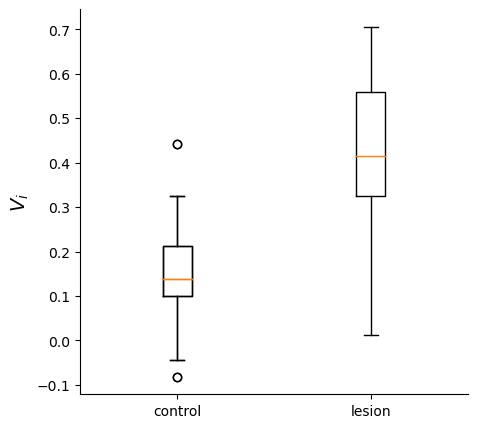

In [27]:
simulation_type = 'eta_nosampling_nodistr_' 

file_type = 'results_sim_type_' + simulation_type + 'eps_'
cs_names = ['10%','50%','90%']
i_group = 0
ieps=0
taus_=np.sort(taus_v[i_group])
eta_ = .5
taus_ = taus_[(taus_>0)*(taus_<1)]
epsilon_ = beta_v[ieps]
agent = create_instance_agent_pav_task(taus_v[1],eta_,epsilon_)
colors_g = ['black','red']
mu_ieps=dict()
mu_ieps['cue_response_mean']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['vi_mean']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['cue_response_mean_n']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['vi_mean_n']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['cue_response_mean_std']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['vi_mean_std']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['cue_response_mean_n_std']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['vi_mean_n_std']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['baseline_vi_mean']=   np.nan*np.ones((len(beta_v),2))
mu_ieps['baseline_vi_mean_std']=   np.nan*np.ones((len(beta_v),2))
for i_eps in range(len(beta_v)):
    eps = beta_v[i_eps]
    eps_str = str(eps).replace('.','_')
    file_list = glob.glob(os.path.join(simulations_dir ,file_type + eps_str +'_control_*'))
    results_control = [np.load(ifile, allow_pickle=True).flatten()[0] for ifile in file_list]
    file_list = glob.glob(os.path.join(simulations_dir ,file_type + eps_str +'_lesion_*'))
    results_lesion = [np.load(ifile, allow_pickle=True).flatten()[0] for ifile in file_list]
    results_l = [rr for rr in results_lesion if len(rr)>0 ]
    results_c = [rr for rr in results_control if len(rr)>0 ]
    #% % Plot means 
    results_v=[results_c,results_l]
    evtype = 'mean'
    vars_n = ['deltas_trials_full','distribution_trials_full']
    save_titles = ['cue_response_mean','vi_mean']
    y_labels = [r'Cue $\delta$',r'$V_i$']
    id_states = [1,3]
    for iv in  np.arange(len(vars_n)):
        var = vars_n[iv]
        id_state = id_states[iv]
        var_mu, var_mu_n = rlplt.get_mean_response_across_iterations(results_v,var,id_state,evtype)
        groups_test =[[var_mu[0,:,ics],var_mu[1,:,ics]] for ics in range(3)]
        name_suff,name_preff = cs_names,save_titles[iv] + '_'+ str(eps)
        tests_pd = get_tests_table(groups_test, name_preff, name_suff,tests_pd = tests_pd )
        
        groups_test =[[var_mu_n[0,:,1],var_mu_n[1,:,1]]]
        name_suff,name_preff = cs_names[1], save_titles[iv] + '_norm' + '_'+ str(eps)
        tests_pd = get_tests_table(groups_test, name_preff, name_suff,tests_pd = tests_pd )

    
    id_cs_plot = np.arange(3)
    id_iter_plot = np.arange(0,len(results_c))
    plot_titles = [r'Cue responses (Data)',r'$V_i$ (Data)']
    fig,ax = rlplt.plot_mean_per_trial_batch_iterations(agent,results_v,vars_n,id_states,save_titles,plot_titles,y_labels,cs_names,g_names,
                                         id_cs_plot,id_iter_plot,simulation_type,[],colors_g,evtype =evtype)    
    
    save_figure_pdf(fig[0],'figure_7f_beta_'+str(np.round(eps,4)),folder =fig_dir)
    save_figure_pdf(fig[1],'figure_7g_beta_'+str(np.round(eps,4)),folder =fig_dir)

    # Plot distribution of baseline: 
    var = 'distribution_trials_full'
    id_state = 0
    title_var =r'$V_i$ baseline (Data)'
    y_title = r'$V_i$'
    save_tit = 'baseline_vi_mean'
    base_resp_g = rlplt.plot_var_baseline_iterations(agent,results_v,var, y_title,g_names,id_state,id_iter_plot,
                                evtype = 'tau')
    tests_pd = get_tests_table([base_resp_g], save_tit, 'all'+ '_'+ str(eps),tests_pd = tests_pd )


tests_pd.to_excel("analysis/stats/Fig7.xlsx")  

- **`Figure_1`** : Reinforcement learning models
- **`Figure_2`** : Biologically inspired reinforcement learning model
- **`Figure_3`** : Potential mechanisms for asymmetric learning.
- **`Figure_4`** : Habenula lesions leads to optimistic reward-seeking behavior and cue-evoked responses in dopamine neurons.
- **`Figure_5`** : Mechanism 2 cannot explain optimistic biases in behavior and cue-evoked dopamine responses of habenula lesioned animals
- **`Figure_6`** : Biophysical model based on firing rates of dopamine neurons predicts increases in dopamine concentration and receptor occupancies at baseline
- **`Figure_7`** : Mechanism 1 can account for optimistic biases in reward-seeking behavior and cue-evoked dopamine responses.
- **`Figure_8`** : Mechanism 1 predicts asymmetric learning rates in healthy humans given inter-individual differences in baseline dopamine.
- **`Figure_Supp_1`**,  **`Figure_Supp_2`** ,**`Figure_Supp_3_and_4`** ,**`Figure_Supp_5`** ,**`Figure_Supp_6`** ,**`Figure_Supp_7_and_8`** ,**`Figure_Supp_9`**


In [14]:
tests_pd

,name_test,pvals,stats,stat_name,alternative,group_nb,group_name,N
0,ttest,0.0,-6.24865,t-statistic,two-sided,2.0,vi_mean_0.02_90%,"[23, 23]"
1,ttest,0.0,-6.382399,t-statistic,two-sided,1.0,vi_mean_0.02_50%,"[23, 23]"
2,ttest,0.000001,-5.804308,t-statistic,two-sided,0.0,vi_mean_0.02_10%,"[23, 23]"
3,normaltest,"[0.14194358773083116, 0.6283317315588598, 0.67...","[3.904651139628999, 0.9293740340291581, 0.7799...",s^2 + k^2,NaN,NaN,vi_mean_0.02_all,"[23, 23, 23, 23, 23, 23]"
4,ranksum,0.000001,4.822235,U-statistic,two-sided,2.0,cue_response_mean_0.02_90%,"[23, 23]"
5,ranksum,0.000001,4.822235,U-statistic,two-sided,1.0,cue_response_mean_0.02_50%,"[23, 23]"
6,ranksum,0.000001,4.822235,U-statistic,two-sided,0.0,cue_response_mean_0.02_10%,"[23, 23]"
7,normaltest,"[0.8026364043984008, 0.6252055563070685, 0.037...","[0.43970692818748053, 0.939349586453833, 6.577...",s^2 + k^2,NaN,NaN,cue_response_mean_0.02_all,"[23, 23, 23, 23, 23, 23]"
8,ttest,0.0,-6.239501,t-statistic,two-sided,2.0,vi_mean_0.015_90%,"[23, 23]"
9,ttest,0.0,-6.396402,t-statistic,two-sided,1.0,vi_mean_0.015_50%,"[23, 23]"
